# Data Visualization: Matplotlib and Seaborn

## Matplotlib

**Matplotlib** features include:

- Create publication quality plots.
- Customize visual style and layout.
- Embed in JupyterLab.

First, we cover some basic usage patterns and best practices to help you get started with Matplotlib.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## A simple example

Matplotlib graphs your data on [`Figure`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure "matplotlib.figure.Figure")s (e.g., windows, Jupyter widgets, etc.), each of which can contain one or more [`Axes`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes "matplotlib.axes.Axes"), an area where points can be specified in terms of x-y coordinates (or theta-r in a polar plot, x-y-z in a 3D plot, etc.).

The simplest way of creating a Figure with an Axes is using [`pyplot.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html#matplotlib.pyplot.subplots "matplotlib.pyplot.subplots"). We can then use [`Axes.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot "matplotlib.axes.Axes.plot") to draw some data on the Axes, and [`show`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html#matplotlib.pyplot.show "matplotlib.pyplot.show") to display the figure:

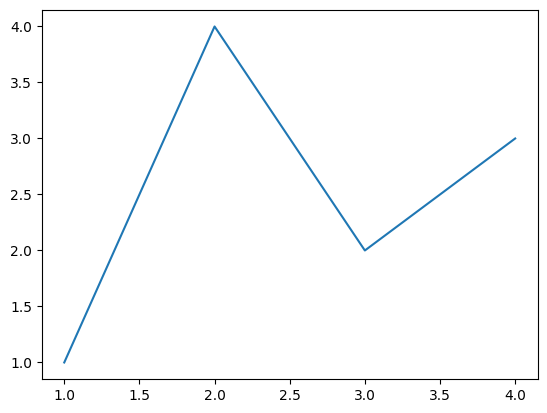

In [2]:
# Create a figure containing a single Axes.
fig, ax = plt.subplots()

# Plot some data on the Axes.
ax.plot(
    [1, 2, 3, 4],
    [1, 4, 2, 3]
) 

# Display all open figures.
plt.show()

Depending on the environment you are working in, `plt.show()` can be left out. This is for example the case with Jupyter notebooks, which automatically show all figures created in a code cell.

### Specifying the x-axis for a function

Let's say we want to draw the Sine function. We first need to specify the x-axis.

We usually use `np.linspace` to create the x-axis by specifying `start` and `stop`, then the number of points `num`:

In [3]:
x = np.linspace(0, 2 * np.pi, 200)
print(x[:5])  # first 5 numbers
print(x[-5:]) # last 5 numbers

[0.         0.0315738  0.06314759 0.09472139 0.12629518]
[6.15689013 6.18846392 6.22003772 6.25161151 6.28318531]


The y-axis would then by a function of x, like so:

In [4]:
y = np.sin(x)

In [5]:
len(x) == len(y)

True

We put the two together in a plot:

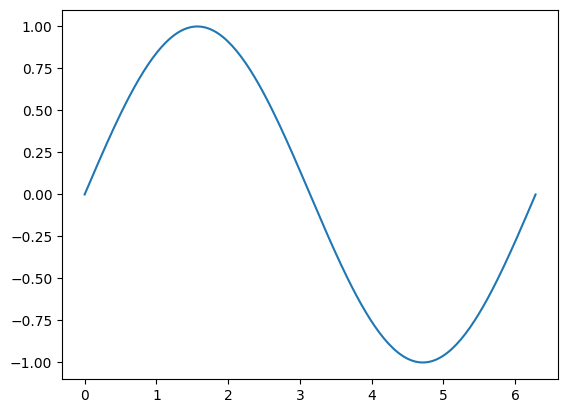

In [6]:
fig, ax = plt.subplots() # Create a figure containing a single Axes.
ax.plot(x, y)            # Plot the data on the Axes.
plt.show()               # Display all open figures.

Let's see how decreasing the number of points affects the shape of the plot:

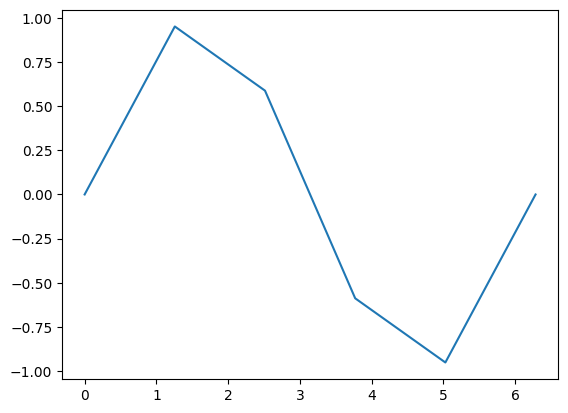

In [7]:
x = np.linspace(0, 2 * np.pi, 6) # Six poitns only
y = np.sin(x)
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

## Parts of a Figure

Here are the components of a Matplotlib Figure.

![](../assets/figure_anatomy.png)

## Coding styles

### The explicit and the implicit interfaces

As noted above, there are essentially two ways to use Matplotlib:

- Explicitly create Figures and Axes, and call methods on them (the "object-oriented (OO) style").
    
- Rely on pyplot to implicitly create and manage the Figures and Axes, and use pyplot functions for plotting.
    

See [Matplotlib Application Interfaces (APIs)](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html#api-interfaces) for an explanation of the tradeoffs between the implicit and explicit interfaces.

So one can use the OO-style

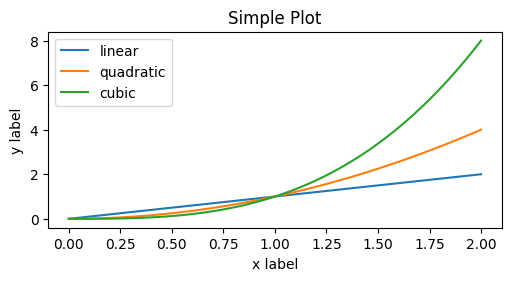

In [8]:
x = np.linspace(0, 2, 100)  # Sample data.

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
ax.plot(x, x, label='linear')  # Plot some data on the Axes.
ax.plot(x, x**2, label='quadratic')  # Plot more data on the Axes...
ax.plot(x, x**3, label='cubic')  # ... and some more.
ax.set_xlabel('x label')  # Add an x-label to the Axes.
ax.set_ylabel('y label')  # Add a y-label to the Axes.
ax.set_title("Simple Plot")  # Add a title to the Axes.
ax.legend()  # Add a legend.

or the pyplot-style:

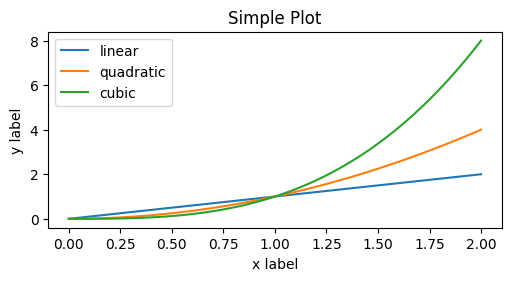

In [9]:
x = np.linspace(0, 2, 100)  # Sample data.

plt.figure(figsize=(5, 2.7), layout='constrained')
plt.plot(x, x, label='linear')  # Plot some data on the (implicit) Axes.
plt.plot(x, x**2, label='quadratic')  # etc.
plt.plot(x, x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Simple Plot")
plt.legend()

Matplotlib's documentation and examples use both the OO and the pyplot styles. **In general, we suggest using the OO style**, particularly for complicated plots, and functions and scripts that are intended to be reused as part of a larger project. However, the pyplot style can be very convenient for quick interactive work.

Interested in more?

- You may want to do [Animations using Matplotlib](https://matplotlib.org/stable/users/explain/animations/index.html).
- You may want to explore [Generating 3D plots using the mplot3d toolkit](https://matplotlib.org/stable/users/explain/toolkits/mplot3d.html).

## Axes and subplots

Matplotlib [`Axes`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes "matplotlib.axes.Axes") are the gateway to creating your data visualizations. Once an Axes is placed on a figure there are many methods that can be used to add data to the Axes. An Axes typically has a pair of [`Axis`](https://matplotlib.org/stable/api/axis_api.html#matplotlib.axis.Axis "matplotlib.axis.Axis") Artists that define the data coordinate system, and include methods to add annotations like x- and y-labels, titles, and legends.

### Basic 2x2 grid

We can create a basic 2-by-2 grid of Axes using [`subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html#matplotlib.pyplot.subplots "matplotlib.pyplot.subplots"). It returns a [`Figure`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure "matplotlib.figure.Figure") instance and an array of [`Axes`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes "matplotlib.axes.Axes") objects. The Axes objects can be used to access methods to place artists on the Axes; here we use [`annotate`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html#matplotlib.axes.Axes.annotate "matplotlib.axes.Axes.annotate"), but other examples could be [`plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot "matplotlib.axes.Axes.plot"), [`pcolormesh`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html#matplotlib.axes.Axes.pcolormesh "matplotlib.axes.Axes.pcolormesh"), etc.

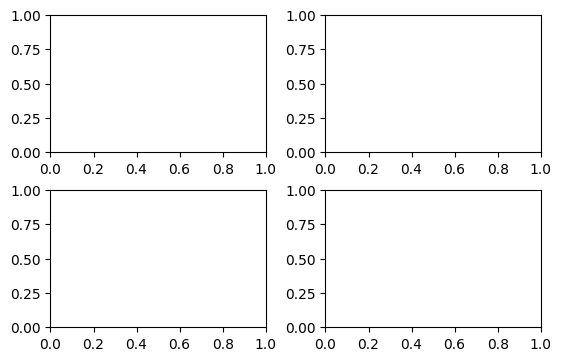

In [10]:
# Sample data.
x = np.linspace(0, 2, 100)

ncols = 2
nrows = 2

fig, axs = plt.subplots(
    ncols=ncols, nrows=nrows,
    figsize=(5.5, 3.5),
    layout="constrained"
)

Let's select each axis and draw something on it this time:

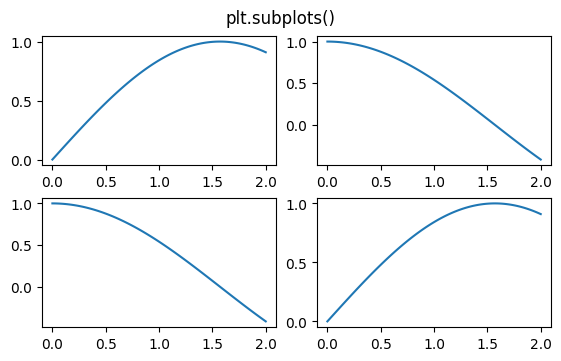

In [11]:
fig, axs = plt.subplots(
    ncols=ncols, nrows=nrows,
    figsize=(5.5, 3.5),
    layout="constrained"
)

funcs = [
    [np.sin, np.cos],
    [np.cos, np.sin]
]

# Using rows and columns
for row in range(nrows):
    for col in range(ncols):
        f = funcs[row][col]
        axs[row, col].plot(x, f(x))

fig.suptitle('plt.subplots()')
plt.show()

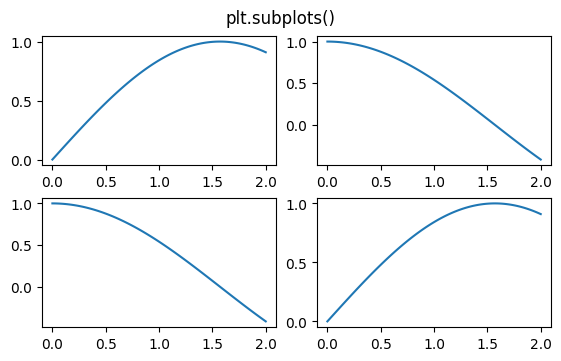

In [12]:
fig, axs = plt.subplots(
    ncols=ncols, nrows=nrows,
    figsize=(5.5, 3.5),
    layout="constrained"
)

funcs = [np.sin, np.cos, np.cos, np.sin]

# Flattening the axes
for i, ax in enumerate(axs.flat):
    f = funcs[i]
    ax.plot(x, f(x))

fig.suptitle('plt.subplots()')
plt.show()

### Axes spanning rows or columns in a grid

Sometimes we want Axes to span rows or columns of the grid. There are actually multiple ways to accomplish this, but the most convenient is probably to use [`subplot_mosaic`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot_mosaic.html#matplotlib.pyplot.subplot_mosaic "matplotlib.pyplot.subplot_mosaic") by repeating one of the keys:

Text(0.5, 0.98, 'plt.subplot_mosaic()')

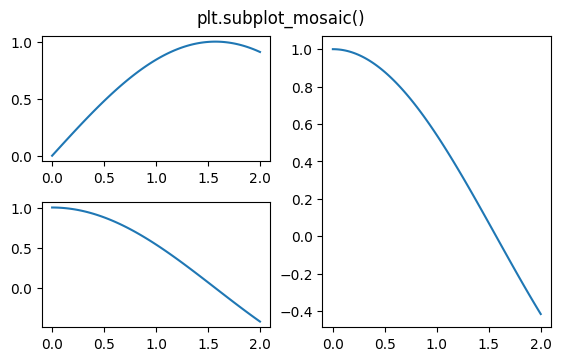

In [13]:
fig, axd = plt.subplot_mosaic([['upper left', 'right'],
                               ['lower left', 'right']],
                              figsize=(5.5, 3.5), layout="constrained")
for i, (k, ax) in enumerate(axd.items()):
    f = funcs[i]
    ax.plot(x, f(x))
fig.suptitle('plt.subplot_mosaic()')

## Seaborn

[Seaborn](https://seaborn.pydata.org/index.html) is a library for making **statistical graphics** in Python. It builds on top of [matplotlib](https://matplotlib.org/) and integrates closely with pandas data structures.

Here you can explore the [gallery of examples](https://seaborn.pydata.org/examples/index.html).

**Seaborn** has additional features for:

- [Multi-plot grids](https://seaborn.pydata.org/tutorial/axis_grids.html)
- [Controlling figure aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html)
  - [Properties of Mark objects](https://seaborn.pydata.org/tutorial/properties.html)
- [Color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)

By convention, the alias `sns` is used for `seaborn`:

In [14]:
import seaborn as sns

## Overview of seaborn plotting functions

Most of your interactions with seaborn will happen through a set of plotting functions. Later chapters in the tutorial will explore the specific features offered by each function. This chapter will introduce, at a high-level, the different kinds of functions that you will encounter.

The `seaborn` namespaces is flat; and has three **Figure-level functions** for three statistical plot types, each of which containing **Axes-level functions**:

1. [Relational plots (`relplot()`)](https://seaborn.pydata.org/api.html#relational-plots) has axes-level functions: `scatterplot()` and `lineplot()`
2. [Distribution plots (`displot()`)](https://seaborn.pydata.org/api.html#distribution-api) has axes-level functions: `histplot()`, ...etc
3. [Categorical plots (`catplot()`)](https://seaborn.pydata.org/api.html#categorical-plots) has axes-level functions: `stripplot()`, ...etc

![](../../assets/seaborn_modules.png)

## Datasets

Seaborn also include datasets for demonstration, like the `penguins`:

In [ ]:
penguins = sns.load_dataset('penguins')

## Figure-level vs Axes-level plot functions

The [distributions module](https://seaborn.pydata.org/api.html#distribution-api) contains several functions designed to answer questions such as these.

1. The **axes-level** functions are [`histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot), [`kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html#seaborn.kdeplot), [`ecdfplot()`](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html#seaborn.ecdfplot), and [`rugplot()`](https://seaborn.pydata.org/generated/seaborn.rugplot.html#seaborn.rugplot).
2. They are grouped together within the **figure-level** [`displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot), [`jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot), and [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) functions.

A distribution plot we will see later is a **Histogram**, we can simply use te `distplot` function and specify the `kind="hist"` (default) as follows:

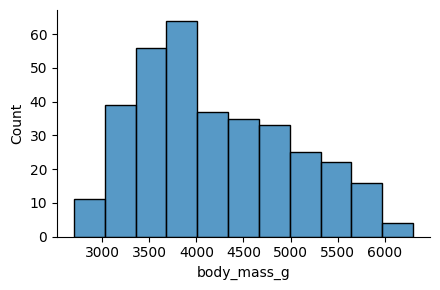

In [17]:
sns.displot(
    penguins, x="body_mass_g",
    aspect=1.5, height=3,
)

### Small Multiples

Seaborn builds on the idea of "Small-Multiples". A **small multiple** (sometimes called **trellis chart**, **lattice chart**, **grid chart**, or **panel chart**) is a series of similar [graphs](https://en.wikipedia.org/wiki/Infographic "Infographic") or [charts](https://en.wikipedia.org/wiki/Chart "Chart") using the same scale and axes, allowing them to be easily compared. It uses multiple views to show different partitions of a [dataset](https://en.wikipedia.org/wiki/Dataset "Dataset"). The term was popularized by [Edward Tufte](https://en.wikipedia.org/wiki/Edward_Tufte "Edward Tufte").

Figure-level can draw multiple subplots (axes) for various use cases using the parameters: `hue`, `col`, `row` as shown below:

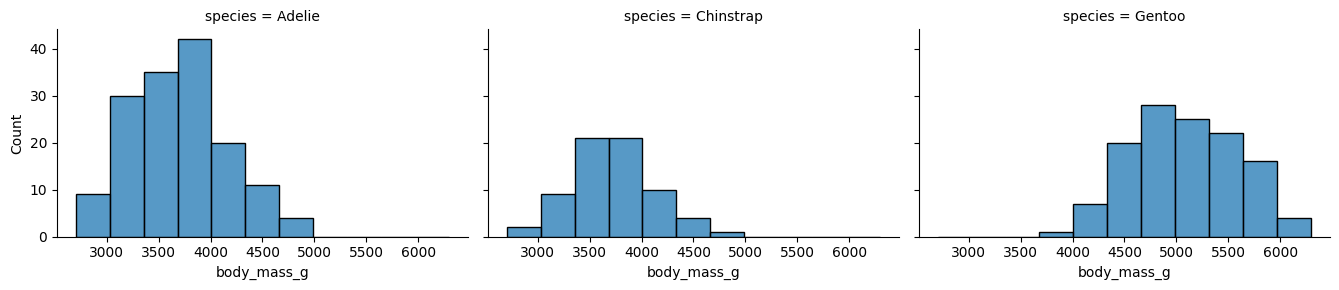

In [18]:
sns.displot(
    data=penguins,
    x="body_mass_g", col="species",
    aspect=1.5, height=3,
)

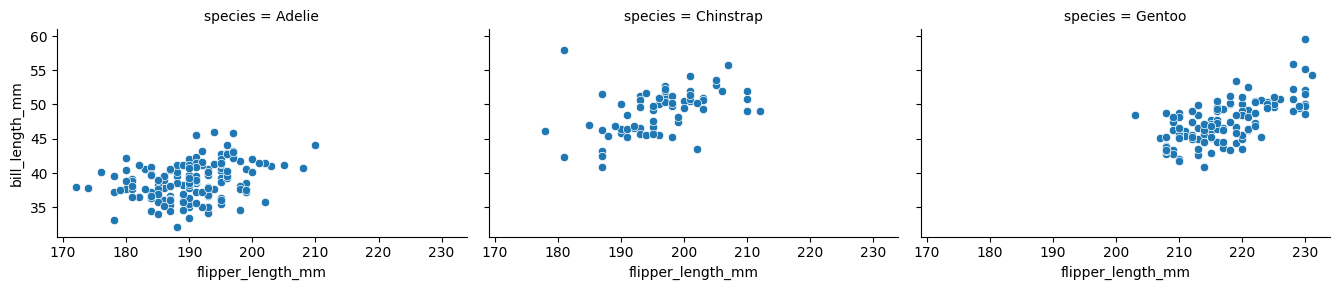

In [19]:
sns.relplot(
    data=penguins,
    x="flipper_length_mm", y="bill_length_mm", col="species",
    aspect=1.5, height=3,
)

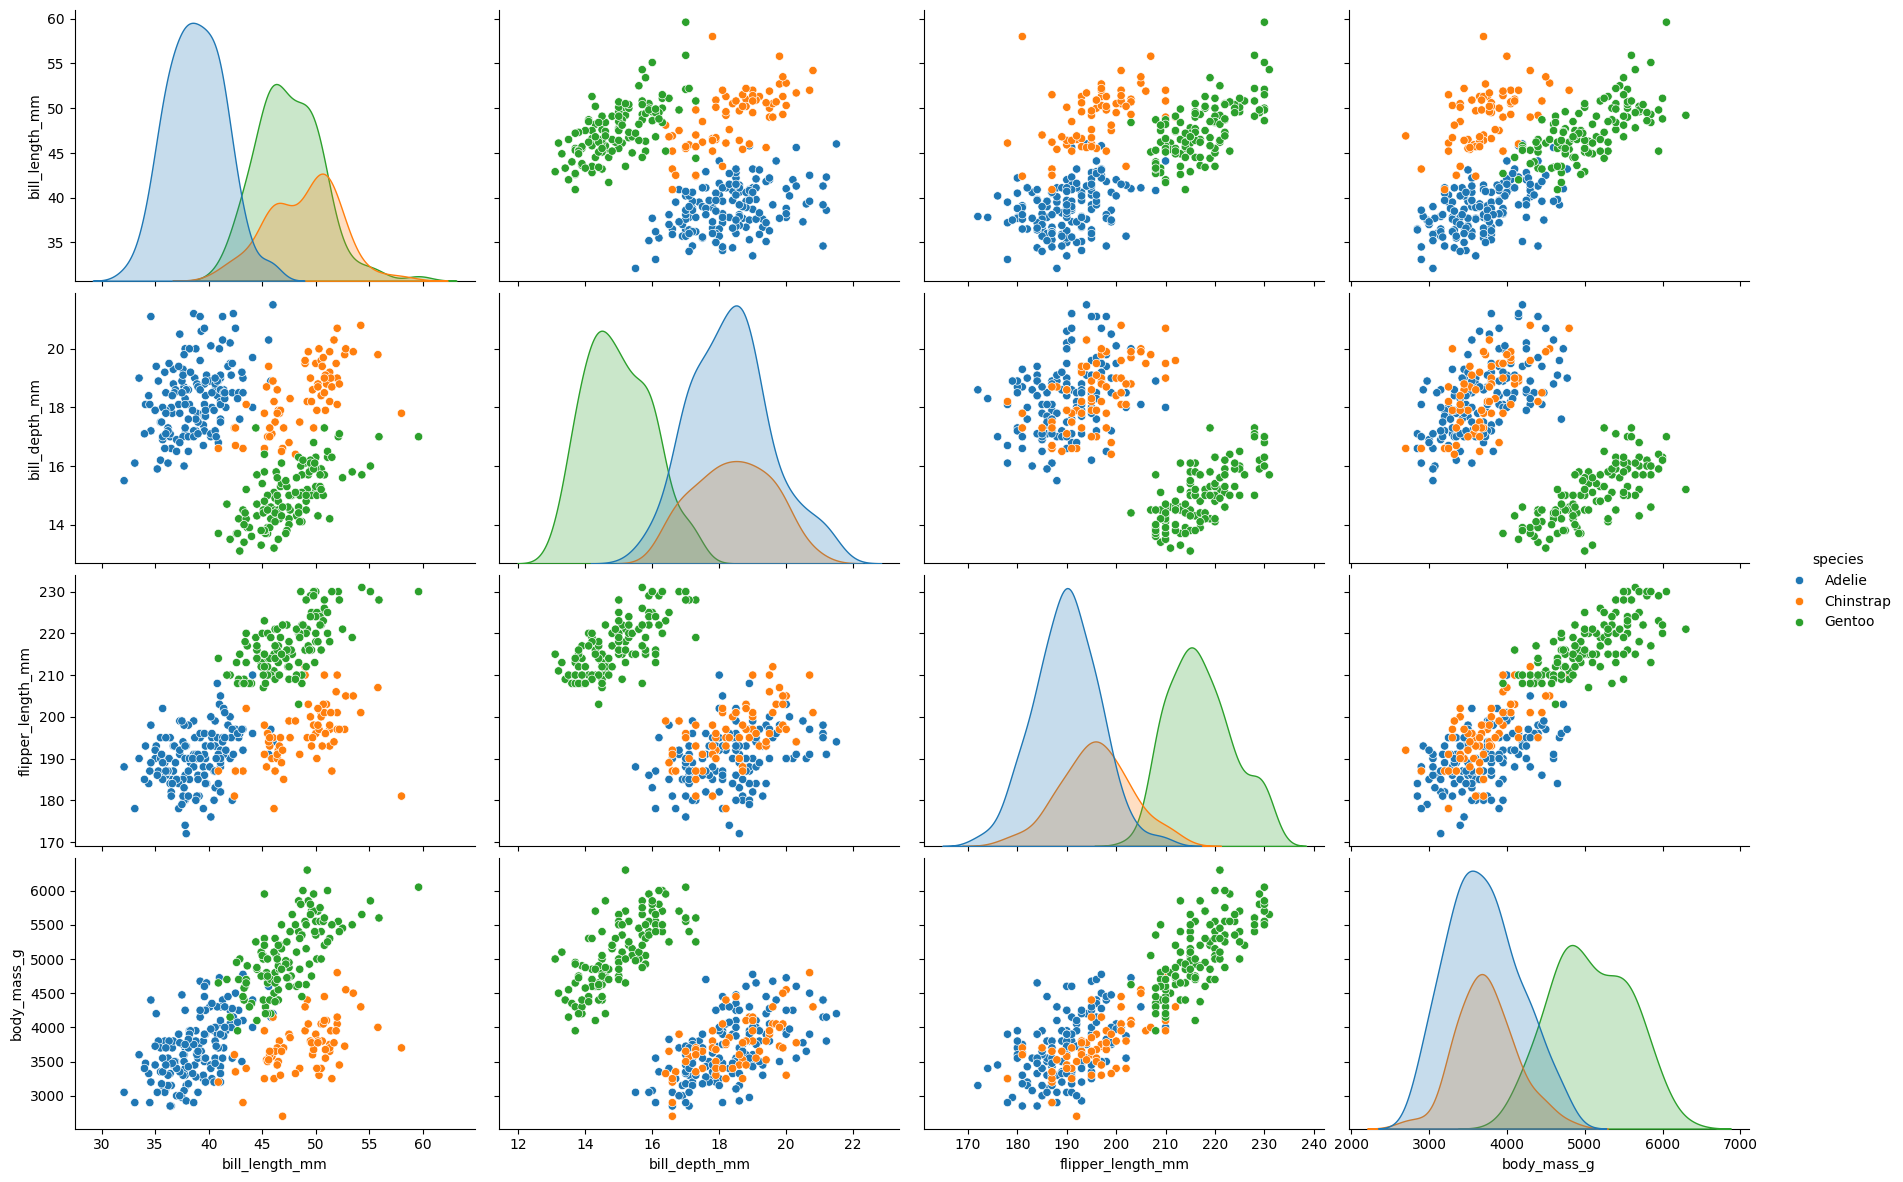

In [20]:
sns.pairplot(
    data=penguins,
    hue="species",
    aspect=1.5, height=3,
)

### Axes-level plot functions (more control)

Wheras `displot` is a figure-level plot, we can use **axes-level plots** like `scatterplot` and `histplot` to draw on individual axes in a subplot for more customization like so:

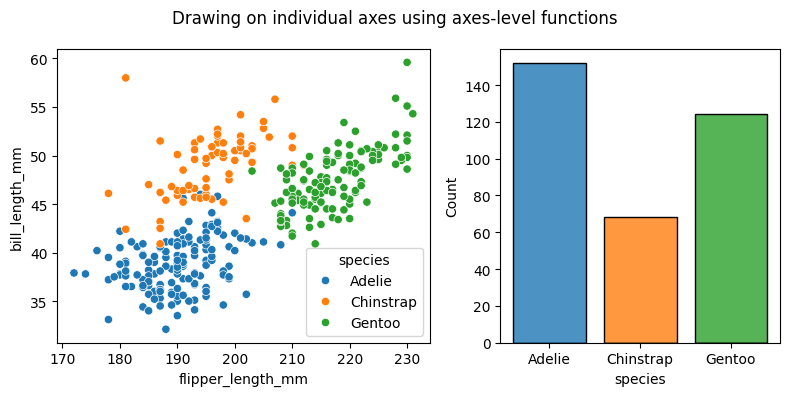

In [ ]:
f, axs = plt.subplots(
    nrows=1, ncols=2,
    figsize=(8, 4),
    gridspec_kw=dict(width_ratios=[4, 3])
)

# Left
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="bill_length_mm",
    hue="species",
    ax=axs[0]
)   

# Right
sns.histplot(
    data=penguins,
    x="species",
    hue="species",
    shrink=.8, alpha=.8, legend=False,
    ax=axs[1]
)

f.suptitle("Drawing on individual axes using axes-level functions")
f.tight_layout()

---

## How to choose the best visualization for the data?

A general approach is to **look at the data types**. With [Data-to-Viz](https://www.data-to-viz.com): You pick the main data type then let the decision tree guide you toward your graphic possibilities. Alternatively, check the complete decision tree.

Alterlatively, you could ask: what is the **goal** of the plot? **Example: proportion, comparison, relationship, ..etc.** You can [Search by Function at DataVizCatalogue](https://datavizcatalogue.com/search.html).

You could always look at this [collection of dataviz **caveats** by data-to-viz.com](https://www.data-to-viz.com/caveats.html), which shows **mistakes** people often make when picking a visualization.

Finally, the coding part: the sequence of steps to make the plot render correctly on the screen as you intended, or save to file. This is where learning tools like `seaborn` and `matplotlib`, or others come in place.

**Please add the above links to your bookmarks.**

## Aesthetics in Seaborn

### Perception

How do we **perceive** quantities from visual properties of a chart?

![](../../assets/perception.png){height=500}

Source Slide deck: [Data Visualization Best Practices — Catherine Mulbrandon](https://speakerdeck.com/cmulbrandon/methods-for-visualizing-economics).

Notice:

- Categorical data represented with **color** and **shape**
- Numerical data represented with varying degrees of accuracy with: **position**, **length**, **slope** & **angle**, **area**, **intensity** & **texture**.

To control graphics in seaborn, checkout the docs:

- [Properties of Mark objects](https://seaborn.pydata.org/tutorial/properties.html)
- [Building structured multi-plot grids](https://seaborn.pydata.org/tutorial/axis_grids.html)
- [Controlling figure aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html)
- [Choosing color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)

Color scheme tools:

- [ColorBrewer 2.0](http://colorbrewer2.org)  
- [Coolors](https://coolors.co/)

## Inspiration

- [DataViz Inspiration](https://www.dataviz-inspiration.com/)
- [NY Times](https://www.nytimes.com/) tends to have incredibly high-quality visualizations that convey information seamlessly.
- [OWID](https://ourworldindata.org/) - Research and data to make progress against the world’s largest problems.
- [Data is Beautiful | Reddit](https://www.reddit.com/r/dataisbeautiful/)
- Bad Examples: [Data is Ugly | Reddit](https://www.reddit.com/r/dataisugly/)

---

## References

- [OpenIntro: Introduction to Modern Statistics](https://openintro-ims.netlify.app/explore-applications)  
- [CS109A | Harvard — Visualization lecture](https://harvard-iacs.github.io/2021-CS109A/lectures/lecture12/presentation/Lecture12_Visualization_2021.pdf)

Other references: the [PyViz.org website](https://pyviz.org/) is an open platform for helping users decide on the best open-source (OSS) Python data visualization tools for their purposes, with links, overviews, comparisons, and examples.